# HoloViews Tutorial - Interactive Plots for Exploratory Data Analysis

In this tutorial, I will be showing you how to make 3 different kinds of HoloViews plots for exploratory data analysis. My example dataset is a Paris housing dataset from Kaggle. The HoloViews website includes much documentation and guidance, but it is not geared very much toward beginners. The purpose of my project is to display information about how to make HoloViews plots in a very beginner-friendly way. The website also does not include very much about best practices with respect to making these visualizations, so I will be explaining how to incorporate best practices from readings we went over in class. I will be boiling these plots down to their simplest forms and then showing step-by-step how to improve them to be high-level plots that can help one explore and display information about a dataset.

After each pair of plots, I will be referencing readings from class to evaluate the plot. Specifically, I will be referencing readings from notable authors in the data visualization field, Edward Tufte and Alberto Cairo with their books, The Visual Display of Quantitative information 2nd Edition and The Truthful Art: Data, Charts, and Maps for Communication, respectively. In their books, they include many helpful tips and guidelines for making data visualizations and we will see how these tips can be implemented in order to visualize data in the most efficient ways possible.

## The Data

First, we need to import pandas to be able to load in the data:

In [1]:
import pandas as pd

In [2]:
ph = pd.read_csv("paris_housing_prices_dataset.csv")

Next, let's take a look at the dataset. The dataset is in good condition and is not in need of cleaning for our purposes. It is very easy to work with and follow. We can see all the most relevant pieces of information about each property. The key variable is price, as for a housing dataset, we typically want to see how different factors impact price. An important step to take with this dataset could eventually be training a model to predict price based on other features. However, an important step to complete first is to get to know the dataset through exploratory data analysis, which is what we will be doing.

In [3]:
ph.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12


## Visualization 1: Scatterplot - Size Vs. Price for Properties with Condition of "New"

First, we will start with all the imports necessary for our main plot, as well as choosing our extension.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
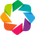

In [4]:
import holoviews as hv 
from holoviews import dim, opts 
from bokeh.models import NumeralTickFormatter 

hv.extension('bokeh')
# HoloViews works by defining the structure of the visualization and using a backend,
# such as Bokeh or Matplotlib to show the plot. 
# Many plots can even be made with multiple packages, so you can use your own preference, but for these examples, I will be using Bokeh

In [5]:
# For Holoviews plots, we need to name our key dimensions and our value dimensions
# Key dimensions define what appears on the axes (positions on the plot, while value dimensions define what is measured at those positions,
# as well as any additional information such as color or tooltips
scatter = hv.Scatter( # Defining the type of plot
    ph, # Make sure to include the name of the dataset
    kdims=['Size_sqm'], # key dimensions
    vdims=['Price_EUR'] # value dimensions
)

scatter

:Scatter   [Size_sqm]   (Price_EUR)

**Improvements to the Plot**

Looking at this plot, there is a lot that one may notice that can be improved. We can see that the y-axis is using scientific notation to display its values. This is a lot less user friendly as extracting information from the plot does not occur as quickly. We can also see how there is no title and the x and y axes are titled by the raw column names. Also, there is an abundance of data in the graph and this leads to lot of overlap. It doesn't help that the graph is also very small. Holoviews plots may seem complicated, but the more we work with them, the more intuitive they become, and these fixes are actually pretty simple.

We will see similar shortcomings with the other plots, and for each one, we will go over how we can improve them and how these improvements fit with Tufte and Cairo's principles in their respective books.

**General Workflow**

Before we get into how to improve the graph, I'd like to introduce a general, beginner-friendly structure for how to make these graphs. I like to think about it as a 3-step process. 

First, we define the graph, data, and dimensions like we did for the simple plot above. 

Next, we may want to change some things about the dimensions, such as the axes labels, the title, or how the numbers are displayed (example: changing from scientific notation). To do this, we define updated dimensions using **hv.Dimension** before creating the plot so that those changes are applied. We can also define a title at this stage. We want to define these above our graph so that the plot uses our updated dimensions.

Finally, we want to be able to customize the plot to our liking. That is where we use **opts**. We do this at the bottom of the code. The possibilities are very numerous with opts, as we can change the size of the graph, the colors, add tooltips, and even change certain aspects of the graphs based on different variables.

In [6]:
ph_new = ph[ph["Condition"] == "New"].copy()

# Before we do anything, to fix the problem of too many overlapping points, let's filter the dataset to only look at a subset of those. 
# I picked to look at only properties with a condition of "New". This way, we can see how the price fluctuates by property size for properties
# of the same condition, making the graph simpler and easier to read

In [7]:
# Got help from chatgpt.com for changing the numbers from scientific notation. Accessed 4/17/26

# Whenever we define a dimension, we can rename it, to improve the label of the axis, making it easier to read for viewers
# This works whether it is in the definition of kdims, vdims, or in a redefinition of a dimension (what we have here)
price_dim = hv.Dimension(
    ('Price_EUR', 'Price (Euros)'), # We make a tuple with the first argument being the raw column name of the variable
    # and the second being what we want to change it to
    value_format=lambda x: f'{x:,.0f}' # Value_format helps to display this dimension in an easy-to-read number format, 
    # as opposed to scientific notation
)
# We make sure to define any dimensions that we want to edit before we define the plot so that we can include the edited dimension 
# in the definition of the plot

title = "Size Vs. Price for Properties with Condition of New" # We can also define a title, which must be done before the definition of the plot
# This is so that we can include the title as the label in that definition

# Now, we have the most important step and what we did in the simple example of a scatterplot
scatter = hv.Scatter( # Define the type of plot
    ph_new, # Define the dataset used (keep in mind this is the filtered data)
    kdims=[('Size_sqm', 'Size (Square Meters)')], # Define our key and value dimensions. This is done the same way as the simple plot, but we make
    # sure to include the tuples to rename the variables. We even want to rename variables not on the axes if we want to use them for tooltips
    vdims=[price_dim, ('Distance_to_Center_km', 'Distance to City Center (km)'), ('Property_Type', 'Property Type')], # here, the only difference is 
    # that when we want to define the price dimension, we call out price dim variable defined earlier so that those changes are implemented
    label = title # We set the label to the title that we made earlier
)

# Now we can really get creative and make changes to our graph.
# Earlier, we had to manually include "scatter" at the bottom to show the simple graph, but opts shows the graph automatically 
scatter.opts(
    opts.Scatter(
        # Here, we can easily add more information to the graph. This line allows us to easily change the colors based on property type 
        # When adding a line like this, first make sure the variable is defined above and use the name that you changed it to in the tuple
        color='Property Type',
        # This line allows us to dictate the size of the points based on the distance to city center. For the sake of simplicity of the graph,
        # I decided to comment this line out. Additionally, with this graph the larger points cause even more overlap
        # I still wanted to show this to display the options we have to display even more information in the graph
        #size = 'Distance to City Center (km)',
        # You can also adjust the size manually. If you don't add this line, a default size will be used 
        size = 7,
        # Here, we can choose the color scheme for the graph. The following link shows different colormaps to choose from that work with holoviews
        # https://holoviews.org/user_guide/Colormaps.html
        cmap='Set1',
        # This line adds borders around all the points. "k" means black
        line_color='k',
        # The alpha value determines the opacity of the points, with 1 being fully solid and 0 being invisible
        # This is a great addition to this graph in particular because it allows us to still see points that are in large overlapped clusters
        alpha=0.4,
        # This line allows us to add tooltips to the graph. When we hover over a point, we will see the values of all the kdims and vdims 
        # associated with that point
        tools=['hover'], 
        # This part defines what we will see in the tooltips and makes sure that the price variable is not shown in scientific notation.
        hover_tooltips=[
            ('Size (Square Meters)', '@{Size (Square Meters)}'),
            ('Price (Euros)', '@{Price (Euros)}{0,0}'),
            ('Distance to Center (km)', '@{Distance to City Center (km)}'),
            ('Property Type', '@{Property Type}')
        ],
        # This line adds gridlines, which for this graph is important to be able to compare points
        show_grid=True,
        # These next 2 lines define the size of the graph. Made it larger than the default to better display the information in a larger format
        width=700,
        height=400,
        # Decides the position of the legend
        legend_position='left',
        # An important line that locks in the numeric showing of the price instead of scientific notation
        yformatter=NumeralTickFormatter(format='0,0')
    )
)

:Scatter   [Size_sqm]   (Price (Euros),Distance to City Center (km),Property Type)

We can easily see how this plot improves upon all the shortcomings of the first one. Here is a brief evaluation of the plot using guidelines from Tufte and Cairo:

This graph has a great data density (Tufte, Chapter 8) and a great data-ink ratio (Tufte, Chapter 6). Tufte explains that these are both very important things to maximize, as we want as much data as possible, without other uses of ink to distract us from that data. The interactive nature of this plot allows us to maximize both of these elements easily. With the hover tooltips, we have access to more data from any point, and tooltips are only shown for the point(s) selected. This means that while non-data ink (Tufte, Chapter 4), may be present in these tooltips, it is only a small amount, and the tooltips give us access to data about any point. This means we have an incredible amount of data at our fingertips with this plot, and the amount of non-data ink needed for that is low, making it worth the tradeoff. The use of showing the property type by making the points different colors also allows us to include even more information packed into a small plot. 

The graph also fits with the 5 qualities of great visualizations (Cairo, Chapter 2). These qualities are: truthfulness, functionality, beauty, insightfulness, and the case of being enlightening. First, the graph is truthful. It is based in honesty, which is a specific characteristic of plots that Cairo emphasizes throughout the book. The graph is not misleading in any way. The labels also include the units so that there is no confusion. Additionally, the title clarifies that the data is only from properties with a condition of "New". Second, the graph is functional. It shows a clear trend in the data and accomplishes its goal of showing how the size of a property affects its price in the dataset. Third, The graph is beautiful. The color palette looks nice and each color goes well with the others. The colors are also not too bright or aggressive. The clear trend of a positive correlation between the main variables is also beautiful in its own way. The gridlines also add beauty because they fill blank space with helpful lines to be able to line the axes up with points more accurately. Fourth, the graph is insightful, as the clear trend allows us to visualize the correlation between these variables and gain insight into how they are correlated. We even see how there is a trend in how the price tends to vary more as we start looking at larger properties. Lastly, the visualization is enlightening because if we learn what is depicted in the graph, as written in Cairo's book, "it will change our minds for the better".

### Visualization 2: Boxplot Chart - Distribution of Property Prices by Condition

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
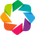

In [8]:
# For each of the 3 main visualizations, I am including the imports again instead of at the top of the notebook
# This is done for clarity, so it is easy to see what is required to run each main example independently.
    
import holoviews as hv
from holoviews import dim

hv.extension('bokeh')

In [9]:
boxwhisker = hv.BoxWhisker( # defining the type of plot
    ph, # Defining the dataset
    ['Condition'], # Defining the categorical variable
    'Price_EUR' # Defining the value dimension
)

boxwhisker

:BoxWhisker   [Condition]   (Price_EUR)

In [10]:
# Defining the dimension for the price to change the values from being shown in scientific notation
price_dim = hv.Dimension(('Price_EUR', 'Price (Euros)'), 
                         value_format=lambda x: f'{x:,.0f}')

title = "Distribution of Prices by Property Condition" # Defining the title

boxwhisker = hv.BoxWhisker( # Defining the type of plot
                ph, # Defining the data
                ['Condition'], # Defining the categorical variable
                price_dim, # Defining the value dimension. Using the new dimension defined above
                label=title) # Implementing the title

boxwhisker.opts(width=600, 
                tools = ['hover'], # Enables hover tooltips
                hover_tooltips=[ # Defines what will be shown in the tooltips. Makes sure the price will not be shown in scientific notation
                ('Condition', '@{Condition}'), 
                ('Median Price', '@{Price (Euros)}{0,0}')], 
                box_fill_color=dim('Condition').str(), # Changes the box color based on property condition
                cmap='Set2', # Defines the colormap
                yformatter=NumeralTickFormatter(format='0,0')) # Formats the y-axis to display numbers instead of scientific notation

:BoxWhisker   [Condition]   (Price (Euros))

This plot was also a very large improvement upon the last one, which was barely readable, due to overlap of labels on the x-axis.

This graph has a beauty to it because of its simplicity, yet high quality output. We are able to see the comparison of the spread of the prices for each level of condition for the properties. We also can look at the tooltip for each boxplot to see the exact number for the median price. There is also no chartjunk (Tufte, Chapter 5). Everything included in the plot is necessary for maintaining its usefulness and if anything was taken away, the plot would likely not be as helpful. Going along with the idea of chartjunk, the graph also goes along with Cairo's emphasis on minimizing decorative elements (Cairo, Chapter 5). There is not an element of the graph that is purely decorative.

The plot also has a high data density (Tufte, Chapter 8), as it shows 4 times the amount of information as one boxplot and is more compact and practical than 4 individual boxplots not on the same axes or 4 histograms. 

Like the first plot, this plot is also very honest, fitting Cairo's teachings within the 5 qualities of great visualizations and throughout the book (Cairo, Chapter 2). Tufte would also agree that this is an honest plot, given its perfect lie factor of 1. A lie factor, according to Tufte is the ratio of the size of an effect shown in a plot to the size of the effect in the data (Tufte, Chapter 2). Given this, a lie factor of 1 would be when differences in values on the graph show the same difference as the data. The graph was made properly and not edited to show exaggerated differences, so naturally it has a perfect lie factor.

### Visualization 3: Heatmap - Median Price by Property Type and Condition

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
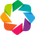

In [11]:
import numpy as np
import holoviews as hv
from holoviews import opts
from bokeh.models import NumeralTickFormatter

hv.extension('bokeh')

In [12]:
# Got help from chatgpt.com to make the each box have the average of price, accessed 4/17/26

heatmap = hv.HeatMap( # Pick the graph type
    ph, # Picks the data
    kdims=['Condition', 'Property_Type'], # Defines the variables for the axes of the heatmap
    vdims=['Price_EUR'] # Defines the value dimension, which will be aggregated and displayed in each square
).aggregate(function=np.mean) # We need to add this line to make the squares on the heatmap equal to the averages of the prices for each
# combination of the two variables

heatmap

:HeatMap   [Condition,Property_Type]   (Price_EUR)

In [13]:
# Price dimension to show numbers in 0,000,000 format
price_dim = hv.Dimension(('Price_EUR', 'Median Price (Euros)'), 
                         value_format=lambda x: f'{x:,.0f}')

title = "Median Price by Property Type and Condition" # Defining the title

heatmap = hv.HeatMap( # Define the plot
    ph, # Define the data
    label = title, # Implementing the title
    kdims=['Condition', ('Property_Type', 'Property Type')], # Define the key dimensions
    vdims=[price_dim] # Define the value dimensions
).aggregate(function=np.median) # Make the squares include the median price for each intersection, not the counts

heatmap.opts(
    opts.HeatMap(
        tools=['hover'], # Add the tooltips
        colorbar=True, # Add the colorbar
        colorbar_opts={'formatter': NumeralTickFormatter(format='0,0')}, # Make the prices on the color bar not scientific notation
        width=500, # Choose the width
        height=400, # Choose the height
        toolbar='below', # For this plot, we may want to specify where the toolbar is. This is because if we let it default, 
        # it will appear to the right of the graph, next to the colorbar, which is less visually appealing
        # If we want the toolbar to be above, we cannot have a title there and must comment out the "label = title" line
        # This is because if we have both a title and the toolbar above, the title is given priority, and there will be no toolbar
        # The only interactive element that is helpful from the toolbar for this heatmap is enabling hover for tooltips, but this is on by default
        # However, if we have no toolbar and we accidentally change the graph by zooming in, the easiest way to revert it is with the reset button
        # on the toolbar
        # Because of this, I chose to implement toolbar = 'below' so that it is more out of the way, but still present
        cmap='Viridis', # Choose the color
    )
)

:HeatMap   [Condition,Property_Type]   (Median Price (Euros))

This graph is arguably underwent the largest improvement when compared to the barebones version. The graph was barely usable before, with no colorbar, x-axis values overlapping, and no tooltips. This makes it very difficult to extract information from the graph. We can only do guesswork to compare the values to each other and we cannot know the exact values.

For the improved graph, we improved virtually every aspect of the plot. Before, it was very difficult to extract information from the plot. Now, the plot is a lot clearer. This goes along with Cairo's teachings about the significance of clarity in graphs (Cairo, Chapter 5). Our x-axis labels are not overlapping now, allowing us to see them. We also have a colorbar to be able to see how the scale works with the colors as well as the values associated with different colors. We also have a wider range of colors, allowing us to more easily differentiate different values. Additionally, we also have our tooltips and our toolbar, allowing us to interact with the graph and also see exact values. Building off of this, the graph especially displays honesty, one of Cairo's most important principles (Cairo, Chapter 2), with how it uses the median values for each box instead of mean values. Medians are often better to look at for exploring data because more extreme values can influence means to go either up or down and not be as representative of the data. Switching the graph to display the median fixes this problem and makes sure that the graph is less likely to be misleading.

The graph also makes sure there is no chartjunk (Tufte, Chapter 5). Every aspect of it contributes to its usefulness. The graph also has great data-density (Tufte, Chapter 8) as it allows us to view the correlation between 3 variables directly all at once. This is much more efficient and makes better use of ink than most 2-variable graphs. 



### How to Use the Toolbar

After learning how these plots are made, it is also important to learn how to interact with them.  One way of doing this is the toolbar. Here, I will explain what each part of the toolbar does, in order. Please keep in mind that this toolbar is Bokeh-specific, so if we use a different extension to show our HoloViews plots, we will not have the toolbar.

**Pan:** When turned on, allows the user to click and drag around the plot to look around. (Often urned on by default)

**Box Zoom:** When turned on, allows the user to click and drag to form a box. The plot then zooms in to show just the part highlighted by the box.

**Wheel Zoom:** When turned on, allows the user to use the mouse scroll wheel to zoom in while hovering over the plot. (Often Turned on by default)

**Save:** Saves the plot to your computer as a png.

**Reset:** Resets the plot to its default state.

**Hover:** When turned on, allows the user to hover over data to see tooltips. (Enabled when included in the code for the plot)

**Bokeh 3.8.0:** Opens a link to the Bokeh website to be able to explore documentation. (Version will vary)


### Final Thoughts

Now, we have gone through how to make three interactive plots to help with exploratory data analysis. HoloViews has a large gallery with many more plots than this, but these were three beginner-friendly ones that hopefully helped you to develop a baseline understanding of how HoloViews works and the ability to employ best practices to create other HoloViews plots, as they follow similar workflows.

Thank you for following this tutorial and I hope you now feel comfortable using HoloViews for exploratory data analysis!

### References

Cairo, Alberto. The Truthful Art: Data, Charts, and Maps for Communication. New Riders, 2016.

Shahid, Eman. “Paris Housing Prices.” Kaggle, https://www.kaggle.com/datasets/syedaeman2212/paris-housing-prices
. Accessed 24 Apr. 2026.

“HoloViews.” HoloViews, https://holoviews.org/
. Accessed 24 Apr. 2026.

OpenAI. ChatGPT. Version April 2026, https://chat.openai.com/
. Accessed 24 Apr. 2026.

Tufte, Edward R. The Visual Display of Quantitative Information. 2nd ed., Graphics Press, 2001.

“Bokeh.” Bokeh, https://bokeh.org/
. Accessed 24 Apr. 2026.